# 20260608 — `g`-factor analysis (Methods A & C)

Computes the anisotropy factor `g = <cos θ>` two independent ways and compares them
(see `LITERATURE_AND_METHOD.md`):

* **Method A — Born / power spectrum** from the structure `.h5` (cheap, no cloud run).
  `dσ/dΩ ∝ P(q) = ⟨|δε̃(q)|²⟩`, `q = 2k sin(θ/2)` → captures the structure-factor physics.
* **Method C — full-wave diffuse far field** from the thin-slab runs: subtract the reference,
  form the diffuse intensity `I_d = ⟨|E|²⟩ − |⟨E⟩|²`, integrate `g` on the regular grid.

(The transport route `g = 1 − ℓs/ℓt` is intentionally out of scope.)

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os, sys, re
from dotenv import load_dotenv
load_dotenv()
import numpy as np
import h5py
import tidy3d as td
from tidy3d import web
from pathlib import Path
import matplotlib.pyplot as plt

for cand in [r'../../../../', r'../../../../../tidy3d', r'H:\\phd stuff\\tidy3d']:
    p = os.path.abspath(cand)
    if os.path.isdir(os.path.join(p, 'AutomationModule')):
        sys.path.append(p); break
from AutomationModule import *
import AutomationModule as AM
import g_tools as gt

In [2]:
tidy3dAPI = os.environ["API_TIDY3D_KEY"]
structure_file = r"../Structures/n_2.90_ff_0.2237.h5"
ff_label = "0.2237"
box_size = 14.3       # um (physical side of the permittivity volume)
n_bg = 1.0            # background (air) index for k = 2*pi*n_bg/lambda

# g is reported vs nu = a/lambda; this range spans the long-wavelength tail (below the
# finite-box floor) up to nu~1.7, so the raw-data NaN floor and the smooth model are both visible.
nu_range = (0.05, 1.7)
n_lambda = 500

## Method A — Born / power-spectrum `g` (no cloud run needed)

First maximum at x = 2.562629142772549, y = 0.021305211552347107


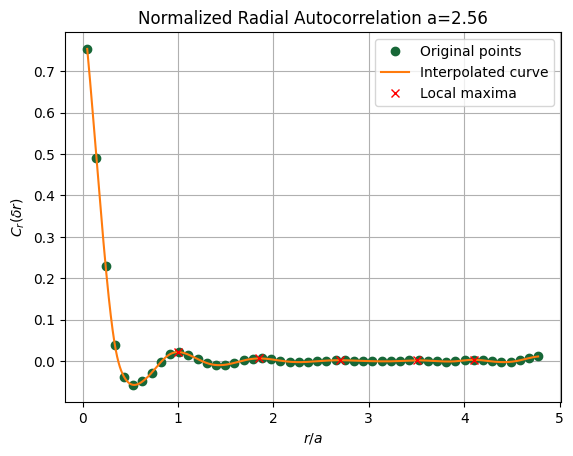

characteristic length a = 2.5626 um
permittivity volume used: (512, 512, 512)
small-q exponent  alpha = 2.30  ->  hyperuniform g_inf = -alpha/(alpha+4) = -0.365
box floor q_box = 2*pi/L = 0.439 rad/um  (nu_floor = a*q_box/(4*pi) = 0.090)


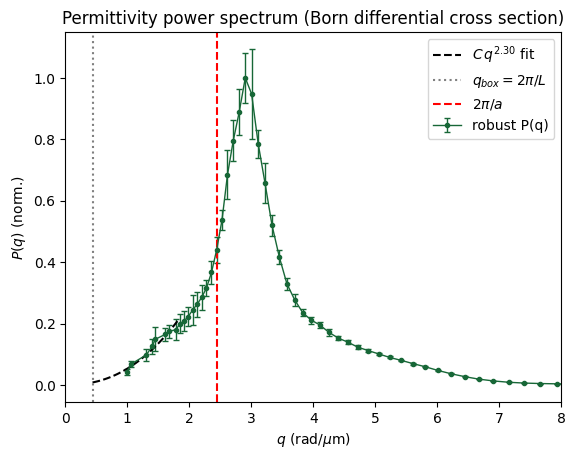

In [3]:
# characteristic length a + robust power spectrum P(q): log bins, per-bin SEM, exponent fit.
# (Windowing/apodization was tested and rejected -- it smears the correlation peak into the
#  suppressed low-q region; clean binning is what recovers the hyperuniform q^alpha trend.)
a_value, _, _ = AM.get_a_from_h5_eps(structure_file, L=box_size, plot_correlation=True)
a = float(a_value)
print('characteristic length a =', round(a, 4), 'um')

ds = 1   # spatial downsample factor; raise to 2 only if RAM-limited (512^3 FFT ~ a few GB)
with h5py.File(structure_file, 'r') as h:
    eps = np.array(h['epsilon'], dtype=float)[::ds, ::ds, ::ds]
print('permittivity volume used:', eps.shape)

q_box = 2.0 * np.pi / box_size
q_r, P_r, P_err = gt.power_spectrum_robust(eps, L=box_size, nbins=160, min_modes=20, smooth=True)
# fit the small-q exponent on the UNSMOOTHED shells (SavGol biases the slope at the edges)
q_f, P_f, _ = gt.power_spectrum_robust(eps, L=box_size, nbins=200, min_modes=10, smooth=False)
alpha, C, g_inf = gt.fit_hyperuniform_exponent(q_f, P_f, L=box_size)
nu_floor = a * q_box / (4.0 * np.pi * n_bg)
print(f'small-q exponent  alpha = {alpha:.2f}  ->  hyperuniform g_inf = -alpha/(alpha+4) = {g_inf:+.3f}')
print(f'box floor q_box = 2*pi/L = {q_box:.3f} rad/um  (nu_floor = a*q_box/(4*pi) = {nu_floor:.3f})')

Pn = P_r / np.nanmax(P_r)
plt.figure()
plt.errorbar(q_r, Pn, yerr=P_err / np.nanmax(P_r), fmt='o-', ms=3, lw=1, capsize=2, label='robust P(q)')
qq = np.linspace(q_box, 0.6 * q_f[(q_f > 2) & (q_f < 3.4)][np.argmax(P_f[(q_f > 2) & (q_f < 3.4)])], 60)
plt.plot(qq, (C * qq ** alpha) / np.nanmax(P_r), 'k--', label=fr'$C\,q^{{{alpha:.2f}}}$ fit')
plt.axvline(q_box, color='gray', ls=':', label=r'$q_{box}=2\pi/L$')
plt.axvline(2 * np.pi / a, color='r', ls='--', label=r'$2\pi/a$')
plt.xlabel(r'$q$ (rad/$\mu$m)'); plt.ylabel(r'$P(q)$ (norm.)')
plt.title('Permittivity power spectrum (Born differential cross section)')
plt.legend(); plt.xlim(0, 8); plt.show()

g_born_from_eps: 12 wavelength(s) below the finite-box floor (2k < q_box = 0.439 rad/length, box L = 14.3); set to NaN. Use a larger structure box to reach those frequencies.


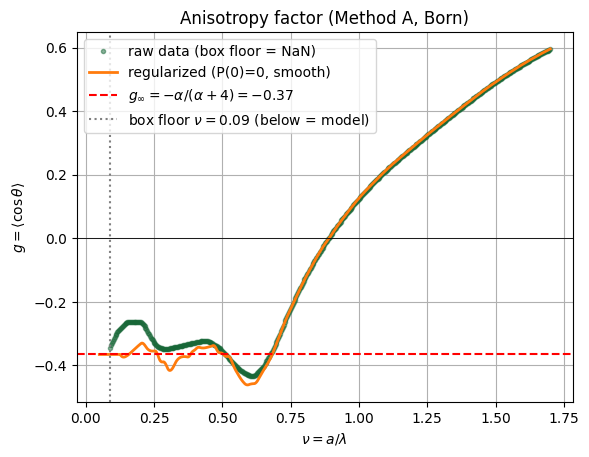

g_born (regularized) range: -0.461 .. 0.596   g_inf = -0.365


In [4]:
# Born g(nu): raw data (NaN below the box floor) vs regularized model (enforces P(0)=0,
# so g is smooth and -> g_inf at long wavelength). They agree where the data is resolved.
lambdas = a / np.linspace(nu_range[0], nu_range[1], n_lambda)
nu = a / lambdas

g_data  = gt.g_born_from_eps(eps, L=box_size, wavelengths=lambdas, n_bg=n_bg,
                             nbins=400, spectrum='raw')
g_born  = gt.g_born_from_eps(eps, L=box_size, wavelengths=lambdas, n_bg=n_bg,
                             nbins=200, spectrum='regularized', allow_extrapolation=True)

plt.figure()
plt.plot(nu, g_data, 'o', ms=3, alpha=0.5, label='raw data (box floor = NaN)')
plt.plot(nu, g_born, '-', lw=2, label='regularized (P(0)=0, smooth)')
plt.axhline(g_inf, color='r', ls='--', label=fr'$g_\infty=-\alpha/(\alpha+4)={g_inf:.2f}$')
plt.axvline(nu_floor, color='gray', ls=':', label=fr'box floor $\nu={nu_floor:.2f}$ (below = model)')
plt.axhline(0, color='k', lw=0.6)
plt.xlabel(r'$\nu = a/\lambda$'); plt.ylabel(r'$g = \langle\cos\theta\rangle$')
plt.title('Anisotropy factor (Method A, Born)'); plt.legend(); plt.grid(True); plt.show()
print('g_born (regularized) range:', round(float(np.nanmin(g_born)), 3),
      '..', round(float(np.nanmax(g_born)), 3), '  g_inf =', round(g_inf, 3))

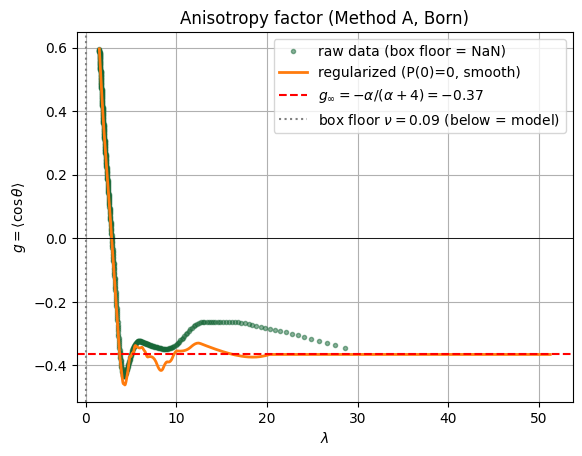

In [9]:
plt.figure()
plt.plot(lambdas, g_data, 'o', ms=3, alpha=0.5, label='raw data (box floor = NaN)')
plt.plot(lambdas, g_born, '-', lw=2, label='regularized (P(0)=0, smooth)')
plt.axhline(g_inf, color='r', ls='--', label=fr'$g_\infty=-\alpha/(\alpha+4)={g_inf:.2f}$')
plt.axvline(nu_floor, color='gray', ls=':', label=fr'box floor $\nu={nu_floor:.2f}$ (below = model)')
plt.axhline(0, color='k', lw=0.6)
plt.xlabel(r'$\lambda$'); plt.ylabel(r'$g = \langle\cos\theta\rangle$')
plt.title('Anisotropy factor (Method A, Born)'); plt.legend(); plt.grid(True); plt.show()

## Method C — full-wave diffuse far field

Loads the thin-slab runs produced by the numerical-experiment notebook (skip if not run yet).
For each realisation: scattered field = structure projection − reference projection. Then form
the coherent `|⟨E⟩|²` and **diffuse** `⟨|E|²⟩ − |⟨E⟩|²` parts and integrate `g`.

With a single realisation the coherent forward lobe cannot be removed by ensemble averaging —
the result is flagged approximate, and azimuthal averaging is used as a partial proxy. Add more
`.h5` realisations to the experiment to get a clean number.

In [5]:
project_name = "20260608_LSU_get_g_factor_v2"
results_root = rf'../../../../data/{project_name}'

# regular grid used by the experiment (must match)
theta, phi = gt.regular_angle_grid(n_theta=181, n_phi=72)

def load_pair(txt_path):
    """Return (E_theta, E_phi, freqs) of the *scattered* field = structure - reference."""
    s = AM.loadFromFile(key=tidy3dAPI, file_path=txt_path, get_ref=True, verbose=False)
    pd  = s.sim_data['field_monitor']
    pd0 = s.sim_data0['field_monitor']
    Et = pd.Etheta.values.squeeze() - pd0.Etheta.values.squeeze()   # (theta, phi, f)
    Ep = pd.Ephi.values.squeeze()   - pd0.Ephi.values.squeeze()
    return Et, Ep, np.asarray(pd.f)   # projection-monitor .f is already an ndarray (no .values)

txts = []
if os.path.isdir(results_root):
    for dp, _, fns in os.walk(results_root):
        txts += [os.path.join(dp, fn) for fn in fns if fn.endswith('.txt')]
print(f'found {len(txts)} result file(s)')
for t in txts: print('  ', t)

found 3 result file(s)
   ../../../../data/20260608_LSU_get_g_factor_v2\n_2.90\LSU_n_2.90_ff_0.2237_t0.5.txt
   ../../../../data/20260608_LSU_get_g_factor_v2\n_2.90\LSU_n_2.90_ff_0.2237_t1.0.txt
   ../../../../data/20260608_LSU_get_g_factor_v2\n_2.90\LSU_n_2.90_ff_0.2237_t2.0.txt


Configured successfully.


19:13:15 W. Europe Daylight Time Billed flex credit cost: 3.879.

                                 Note: the task cost pro-rated due to early     
                                 shutoff was below the minimum threshold, due to
                                 fast shutoff. Decreasing the simulation        
                                 'run_time' should decrease the estimated, and  
                                 correspondingly the billed cost of such tasks.

[t=0.5.] WARNING: single realisation. g here is dominated by the coherent forward lobe of the finite slab (azimuthally symmetric -> phi-averaging does not remove it), so it is NOT the diffuse phase-function g and it drifts with thickness. For a valid g, add independent realisations (same statistics, different seed) so the ensemble <E> can be subtracted; keep the slab thin.
Configured successfully.


19:13:17 W. Europe Daylight Time Billed flex credit cost: 3.960.

                                 Note: the task cost pro-rated due to early     
                                 shutoff was below the minimum threshold, due to
                                 fast shutoff. Decreasing the simulation        
                                 'run_time' should decrease the estimated, and  
                                 correspondingly the billed cost of such tasks.

[t=1.0.] WARNING: single realisation. g here is dominated by the coherent forward lobe of the finite slab (azimuthally symmetric -> phi-averaging does not remove it), so it is NOT the diffuse phase-function g and it drifts with thickness. For a valid g, add independent realisations (same statistics, different seed) so the ensemble <E> can be subtracted; keep the slab thin.
Configured successfully.


19:13:19 W. Europe Daylight Time Billed flex credit cost: 4.158.

                                 Note: the task cost pro-rated due to early     
                                 shutoff was below the minimum threshold, due to
                                 fast shutoff. Decreasing the simulation        
                                 'run_time' should decrease the estimated, and  
                                 correspondingly the billed cost of such tasks.

[t=2.0.] WARNING: single realisation. g here is dominated by the coherent forward lobe of the finite slab (azimuthally symmetric -> phi-averaging does not remove it), so it is NOT the diffuse phase-function g and it drifts with thickness. For a valid g, add independent realisations (same statistics, different seed) so the ensemble <E> can be subtracted; keep the slab thin.


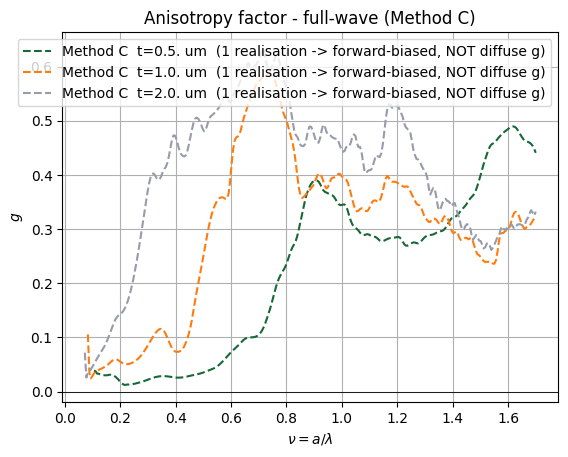

In [6]:
g_fullwave = {}
if txts:
    import collections
    groups = collections.defaultdict(list)
    for t in txts:
        tag = re.search(r'_t([\d.]+)', os.path.basename(t))
        groups[tag.group(1) if tag else 'na'].append(t)

    for tag, files in sorted(groups.items()):
        Et_list, Ep_list, freqs = [], [], None
        for fp in files:
            try:
                Et, Ep, freqs = load_pair(fp)
                Et_list.append(Et); Ep_list.append(Ep)
            except Exception as e:
                print('skip', fp, e)
        if not Et_list:
            continue
        Et = np.stack(Et_list, 0); Ep = np.stack(Ep_list, 0)   # (n_real, theta, phi, f)
        n_real = Et.shape[0]
        lam = td.C_0 / freqs

        if n_real >= 2:
            # proper ensemble coherent subtraction -> diffuse phase function
            I_use = gt.coherent_incoherent(Et)['diffuse'] + gt.coherent_incoherent(Ep)['diffuse']
            label = f'Method C  t={tag} um  (diffuse, n_real={n_real})'
            style = '-'
        else:
            # ONE realisation: the coherent FORWARD lobe cannot be removed. It is azimuthally
            # symmetric, so averaging over phi does NOT separate it from the diffuse part
            # (verified: phi-averaged coherent subtraction leaves g essentially unchanged).
            # This curve is the raw scattered |E|^2 -> forward-biased and thickness-dependent,
            # i.e. NOT the transport/diffuse g. Shown dashed, as a placeholder only.
            I_use = (np.abs(Et[0]) ** 2 + np.abs(Ep[0]) ** 2)
            label = f'Method C  t={tag} um  (1 realisation -> forward-biased, NOT diffuse g)'
            style = '--'
            print(f'[t={tag}] WARNING: single realisation. g here is dominated by the coherent '
                  f'forward lobe of the finite slab (azimuthally symmetric -> phi-averaging does '
                  f'not remove it), so it is NOT the diffuse phase-function g and it drifts with '
                  f'thickness. For a valid g, add independent realisations (same statistics, '
                  f'different seed) so the ensemble <E> can be subtracted; keep the slab thin.')

        g = gt.asymmetry_parameter(theta, phi, I_use)
        g_fullwave[tag] = (a / lam, np.asarray(g))
        plt.plot(a / lam, g, style, label=label)

    plt.axhline(0, color='k', lw=0.6)
    plt.xlabel(r'$\nu=a/\lambda$'); plt.ylabel(r'$g$'); plt.legend(); plt.grid(True)
    plt.title('Anisotropy factor - full-wave (Method C)'); plt.show()
else:
    print('No full-wave results yet. Run 20260608_numerical_experiment.ipynb with RUN=True.')

## Compare Methods A & C, and save

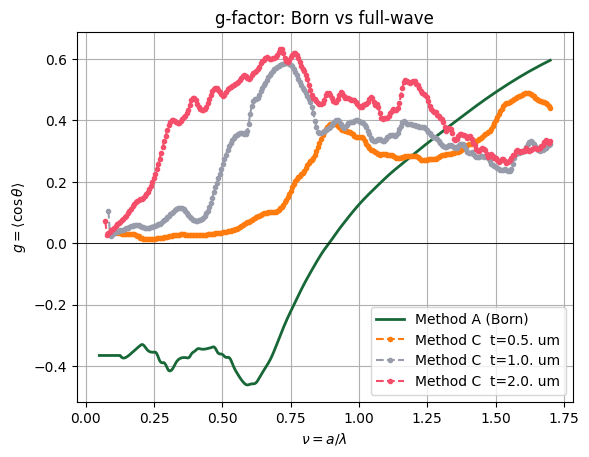

In [7]:
plt.figure()
plt.plot(a / lambdas, g_born, '-', lw=2, label='Method A (Born)')
for tag, (nu, g) in sorted(g_fullwave.items()):
    plt.plot(nu, g, '--o', ms=3, label=f'Method C  t={tag} um')
plt.axhline(0, color='k', lw=0.6)
plt.xlabel(r'$\nu=a/\lambda$'); plt.ylabel(r'$g=\langle\cos\theta\rangle$')
plt.title('g-factor: Born vs full-wave'); plt.legend(); plt.grid(True); plt.show()

In [8]:
out = {'a': a, 'lambdas': lambdas, 'nu': a / lambdas,
       'g_born_regularized': g_born, 'g_born_data': g_data,
       'alpha': alpha, 'g_inf': g_inf, 'q_box': q_box, 'nu_floor': nu_floor}
for tag, (nu_c, g) in g_fullwave.items():
    out[f'g_fullwave_t{tag}'] = g
    out[f'nu_fullwave_t{tag}'] = nu_c

folder = './data/g_values'
os.makedirs(folder, exist_ok=True)
AM.create_hdf5_from_dict({ff_label: out}, folder + '/20260608_g_values_n_3p3_ff_22p37_v2.h5')
print('saved ->', folder + '/20260608_g_values_n_3p3_ff_22p37_v2.h5')

saved -> ./data/g_values/20260608_g_values_n_3p3_ff_22p37_v2.h5
